## NOTEBOOK 5

This notebook presents the final pipeline for data preprocessing, feature engineering, model training, and evaluation with relevant visualizations. Four models were explored:  XGBoost, CatBoost, SARIMAX, and a Neural Network. XGBoost was selected as the
final model for the application due to having the best performance metrics.

In [42]:
#importing necessary libraries
import pandas as pd
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid

In [2]:
 #loading dataset
df = pd.read_csv("../Data/ProductionForecastingDataset.csv")

In [3]:
df.shape

(115, 12)

In [4]:
#null/missing values
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
EVI                   30
NDVI                  30
yield                 19
dtype: int64

In [5]:
#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))
df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())


   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


In [6]:
#adding the code to show seasonality
df["sin_month"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month_num"] / 12)



In [7]:
df = df.dropna(subset=['yield']).reset_index(drop=True)

In [8]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_momentum'] = df['yield_lag_1'] - df['yield_lag_2']
df['yield_lag_3']=df['yield'].shift(3)
df['yield_lag_12'] = df['yield'].shift(12)

df = df.dropna(subset=['yield_lag_1','yield_lag_2','yield_lag_3','yield_lag_12','yield_momentum']).reset_index(drop=True)


In [9]:
df = df.drop(columns=["month_num"])

In [10]:
df.head(20)

,year,month,wet_days,rainfall,temperature_T2M,irradiance_SW_DWN,EVI,NDVI,yield,total_workforce,female_workforceRatio,sin_month,cos_month,yield_lag_1,yield_lag_2,yield_momentum,yield_lag_3,yield_lag_12
0,2018,April,20.0,373.0,24.06,5.4674,NaN,NaN,72012.0,790.0,0.562025,8.660254e-01,-5.000000e-01,66298.0,57908.0,8390.0,61705.0,75563.0
1,2018,May,26.0,831.0,23.42,4.3080,NaN,NaN,71540.0,790.0,0.562025,5.000000e-01,-8.660254e-01,72012.0,66298.0,5714.0,57908.0,72131.0
2,2018,June,30.0,932.0,22.78,4.6841,NaN,NaN,38362.0,790.0,0.562025,1.224647e-16,-1.000000e+00,71540.0,72012.0,-472.0,66298.0,37098.0
3,2018,July,26.0,809.0,22.38,4.8886,0.239560,0.172064,23203.0,790.0,0.562025,-5.000000e-01,-8.660254e-01,38362.0,71540.0,-33178.0,72012.0,49853.0
4,2018,August,20.0,1055.0,22.18,4.7866,NaN,NaN,26498.0,790.0,0.562025,-8.660254e-01,-5.000000e-01,23203.0,38362.0,-15159.0,71540.0,39997.0
5,2018,September,13.0,275.0,22.83,5.6302,NaN,NaN,39000.0,790.0,0.562025,-1.000000e+00,-1.836970e-16,26498.0,23203.0,3295.0,38362.0,40881.0
6,2018,October,24.0,480.0,22.56,4.5480,NaN,NaN,88699.0,790.0,0.562025,-8.660254e-01,5.000000e-01,39000.0,26498.0,12502.0,23203.0,47635.0
7,2018,November,18.0,231.0,22.28,4.7153,NaN,NaN,46082.0,790.0,0.562025,-5.000000e-01,8.660254e-01,88699.0,39000.0,49699.0,26498.0,48275.0
8,2018,December,9.0,219.0,21.47,4.8010,0.531585,0.689903,53217.0,790.0,0.562025,-2.449294e-16,1.000000e+00,46082.0,88699.0,-42617.0,39000.0,58527.0
9,2019,January,3.0,48.0,21.22,5.4893,0.502249,0.728006,45298.0,746.0,0.569705,5.000000e-01,8.660254e-01,53217.0,46082.0,7135.0,88699.0,61705.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   84 non-null     int64  
 1   month                  84 non-null     object 
 2   wet_days               80 non-null     float64
 3   rainfall               80 non-null     float64
 4   temperature_T2M        84 non-null     float64
 5   irradiance_SW_DWN      84 non-null     float64
 6   EVI                    77 non-null     float64
 7   NDVI                   77 non-null     float64
 8   yield                  84 non-null     float64
 9   total_workforce        84 non-null     float64
 10  female_workforceRatio  84 non-null     float64
 11  sin_month              84 non-null     float64
 12  cos_month              84 non-null     float64
 13  yield_lag_1            84 non-null     float64
 14  yield_lag_2            84 non-null     float64
 15  yield_mo

In [12]:
df.shape

(84, 18)

In [13]:
features = ['rainfall','wet_days','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','yield_lag_12','irradiance_SW_DWN','sin_month','cos_month','NDVI','EVI','yield_momentum']    #added sin_month and cos_month to features-15.02.2026

target = ['yield']
X=df[features]
Y=df[target]

In [14]:
split_idx=int(len(df)*0.85)
x_train = X.iloc[:split_idx].copy()
y_train = Y.iloc[:split_idx].copy()
x_test = X.iloc[split_idx:].copy()
y_test = Y.iloc[split_idx:].copy()

In [15]:
# Compute month-wise median rainfall from TRAINING set only
rainfall_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['rainfall'].median()

# Impute training set
x_train['rainfall'] = x_train.apply(
    lambda row: rainfall_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['rainfall']) else row['rainfall'], axis=1
)

# Impute test set using the SAME train-derived medians
x_test['rainfall'] = x_test.apply(
    lambda row: rainfall_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['rainfall']) else row['rainfall'], axis=1
)

In [16]:
# Compute month-wise median wet_days from TRAINING set only
wet_days_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['wet_days'].median()

# Impute training set
x_train['wet_days'] = x_train.apply(
    lambda row: wet_days_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['wet_days']) else row['wet_days'], axis=1
)

# Impute test set using the SAME train-derived medians
x_test['wet_days'] = x_test.apply(
    lambda row: wet_days_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['wet_days']) else row['wet_days'], axis=1
)

In [17]:
#NDVI

#Compute IQR bounds from TRAINING set only
Q1_ndvi = x_train['NDVI'].quantile(0.25)
Q3_ndvi = x_train['NDVI'].quantile(0.75)
IQR_ndvi = Q3_ndvi - Q1_ndvi
lower_ndvi = Q1_ndvi - 1.5 * IQR_ndvi
upper_ndvi = Q3_ndvi + 1.5 * IQR_ndvi

#Replace outliers with NaN (train and test using TRAIN bounds)
x_train['NDVI'] = x_train['NDVI'].where(
    (x_train['NDVI'] >= lower_ndvi) & (x_train['NDVI'] <= upper_ndvi), np.nan
)
x_test['NDVI'] = x_test['NDVI'].where(
    (x_test['NDVI'] >= lower_ndvi) & (x_test['NDVI'] <= upper_ndvi), np.nan
)

#Compute month-wise median from TRAINING set (after outlier removal)
ndvi_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['NDVI'].median()

#Impute training set
x_train['NDVI'] = x_train.apply(
    lambda row: ndvi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['NDVI']) else row['NDVI'], axis=1
)

#Impute test set using SAME train-derived medians
x_test['NDVI'] = x_test.apply(
    lambda row: ndvi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['NDVI']) else row['NDVI'], axis=1
)


#EVI

#Compute IQR bounds from TRAINING set only
Q1_evi = x_train['EVI'].quantile(0.25)
Q3_evi = x_train['EVI'].quantile(0.75)
IQR_evi = Q3_evi - Q1_evi
lower_evi = Q1_evi - 1.5 * IQR_evi
upper_evi = Q3_evi + 1.5 * IQR_evi

#Replace outliers with NaN (train and test using TRAIN bounds)
x_train['EVI'] = x_train['EVI'].where(
    (x_train['EVI'] >= lower_evi) & (x_train['EVI'] <= upper_evi), np.nan
)
x_test['EVI'] = x_test['EVI'].where(
    (x_test['EVI'] >= lower_evi) & (x_test['EVI'] <= upper_evi), np.nan
)

#Compute month-wise median from TRAINING set (after outlier removal)
evi_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['EVI'].median()

#Impute training set
x_train['EVI'] = x_train.apply(
    lambda row: evi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['EVI']) else row['EVI'], axis=1
)

#Impute test set using SAME train-derived medians
x_test['EVI'] = x_test.apply(
    lambda row: evi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['EVI']) else row['EVI'], axis=1
)

In [18]:
#Concatenate to create lag correctly across the split boundary
combined = pd.concat([x_train, x_test])
combined['rainfall_lag_1'] = combined['rainfall'].shift(1)

#Split back
x_train['rainfall_lag_1'] = combined['rainfall_lag_1'].iloc[:len(x_train)].values
x_test['rainfall_lag_1']  = combined['rainfall_lag_1'].iloc[len(x_train):].values

#Impute the NaN in the first row of x_train using train median
rainfall_lag_median = x_train['rainfall_lag_1'].median()
x_train['rainfall_lag_1'] = x_train['rainfall_lag_1'].fillna(rainfall_lag_median)

#Add to features list
features = ['rainfall','wet_days','female_workforceRatio',
             'yield_lag_1', 'yield_lag_2', 'yield_lag_3','yield_lag_12','rainfall_lag_1',
             'irradiance_SW_DWN', 'sin_month', 'cos_month','NDVI','EVI','yield_momentum']

In [19]:
x_train = x_train[features]
x_test  = x_test[features]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only, transform both
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Convert back to DataFrame to keep column names
x_train_scaled = pd.DataFrame(x_train_scaled, columns=features, index=x_train.index)
x_test_scaled  = pd.DataFrame(x_test_scaled,  columns=features, index=x_test.index)

In [21]:
#SARIMAX MODEL
#SARIMAX MODEL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# SARIMAX uses raw yield as endogenous (time series)
sarimax_train = df['yield'].iloc[:split_idx].reset_index(drop=True)
sarimax_test  = df['yield'].iloc[split_idx:].reset_index(drop=True)

# Exogenous variables:
#Climate + vegetation + seasonality + labour (female ratio as representative workforce variable)
#Lag features excluded: SARIMAX captures autocorrelation internally via AR/seasonal AR terms
#total_workforce excluded: correlated with female_workforceRatio (derived from same source)
exog_cols_sarimax = ['rainfall', 'wet_days', 'irradiance_SW_DWN',
                     'NDVI', 'EVI', 'sin_month', 'cos_month',
                     'female_workforceRatio']

exog_train = x_train[exog_cols_sarimax].values
exog_test  = x_test[exog_cols_sarimax].values

In [22]:
# Automatically search for best (p,d,q)(P,D,Q,12) using AIC
auto_model = auto_arima(
    sarimax_train,
    exogenous=exog_train,
    seasonal=True,
    m=12,                        # monthly seasonality (yearly cycle)
    d=None,                      # auto-detect differencing
    D=None,                      # auto-detect seasonal differencing
    stepwise=True,               # faster search
    information_criterion='aic', # select best model by AIC
    trace=True,                  # prints all tested combinations
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
print(f"\nBest ARIMA order          : {auto_model.order}")
print(f"Best seasonal order (s=12): {auto_model.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1555.741, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1554.026, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1539.967, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1553.818, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.03 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1536.805, Time=0.28 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1538.728, Time=0.43 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1558.910, Time=0.04 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=1537.143, Time=0.11 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=1541.643, Time=0.11 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1555.734, Time=0.06 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=1542.122, Time=0.13 sec
 ARIMA(0,1,1)(0,0,2)[12]          

In [23]:
best_order          = auto_model.order
best_seasonal_order = auto_model.seasonal_order

sarimax_model = SARIMAX(
    sarimax_train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)
print(sarimax_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  yield   No. Observations:                   71
Model:               SARIMAX(5, 1, 1)   Log Likelihood                -690.839
Date:                Sat, 04 Apr 2026   AIC                           1411.678
Time:                        23:10:09   BIC                           1444.293
Sample:                             0   HQIC                          1424.547
                                 - 71                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2879      6.240      0.046      0.963     -11.942      12.518
x2          -259.2055    393.580     -0.659      0.510   -1030.607     512.196
x3         -7396.9870   4223.058     -1.752      0.0

In [24]:
sarimax_forecast = sarimax_result.forecast(
    steps=len(sarimax_test),
    exog=exog_test
)
y_pred_sarimax = sarimax_forecast.values

In [25]:
sarimax_rmse = np.sqrt(mean_squared_error(sarimax_test, y_pred_sarimax))
sarimax_mae  = mean_absolute_error(sarimax_test, y_pred_sarimax)
sarimax_r2   = r2_score(sarimax_test, y_pred_sarimax)

print("SARIMAX Yield Prediction Performance")
print(f"RMSE: {sarimax_rmse:.2f}")
print(f"MAE : {sarimax_mae:.2f}")
print(f"R²  : {sarimax_r2:.3f}")

SARIMAX Yield Prediction Performance
RMSE: 8565.62
MAE : 7973.97
R²  : 0.054


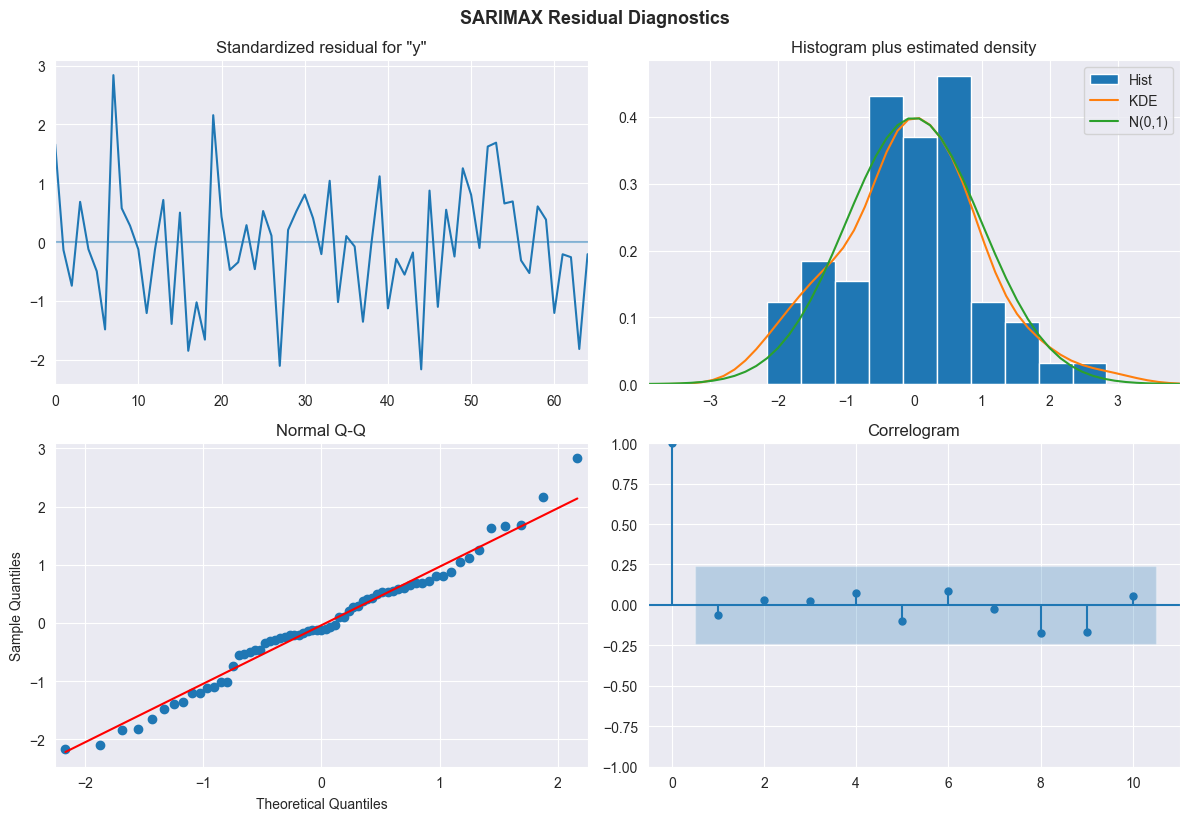

Ljung-Box Test (lag=10)
      lb_stat  lb_pvalue
10  14.234904   0.162544

✓ p-value > 0.05 — No significant autocorrelation in residuals.
  Residuals behave as white noise. Model is well-specified.


In [26]:
#SARIMAX Residual Diagnostics
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plot diagnostics (residual plot, ACF, histogram, Q-Q plot)
sarimax_result.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.suptitle("SARIMAX Residual Diagnostics", y=1.02, fontsize=13, fontweight='bold')
plt.show()

# Ljung-Box test — tests if residuals are white noise
lb_test = acorr_ljungbox(sarimax_result.resid, lags=[10], return_df=True)
print("Ljung-Box Test (lag=10)")
print(lb_test)
print()
if lb_test['lb_pvalue'].values[0] > 0.05:
    print("✓ p-value > 0.05 — No significant autocorrelation in residuals.")
    print("  Residuals behave as white noise. Model is well-specified.")
else:
    print("✗ p-value ≤ 0.05 — Autocorrelation detected in residuals.")
    print("  Consider adjusting ARIMA orders.")

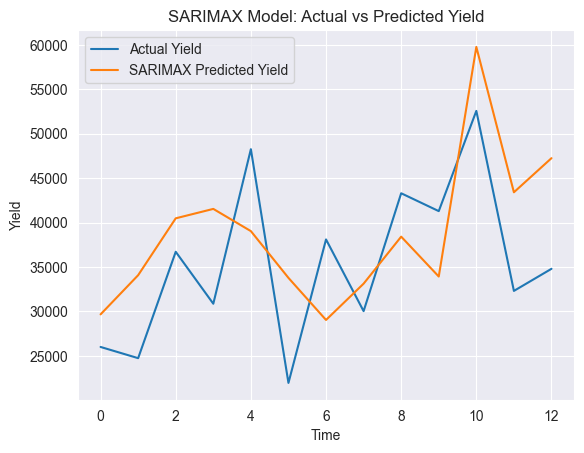

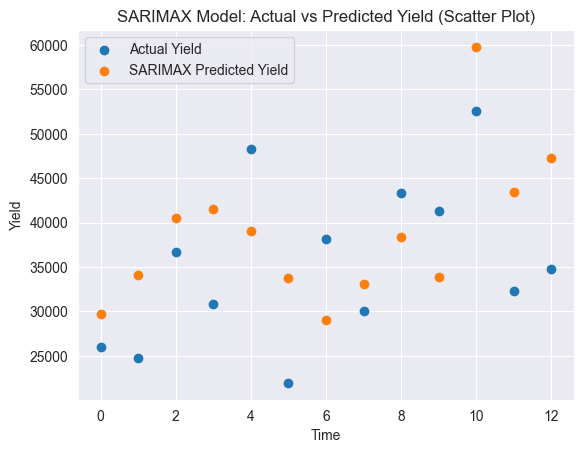

In [27]:
# Line plot
plt.figure()
plt.plot(sarimax_test.index, sarimax_test.values, label="Actual Yield")
plt.plot(sarimax_test.index, y_pred_sarimax,      label="SARIMAX Predicted Yield")
plt.legend()
plt.title("SARIMAX Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()

# Scatter plot
plt.figure()
plt.scatter(sarimax_test.index, sarimax_test.values, label="Actual Yield")
plt.scatter(sarimax_test.index, y_pred_sarimax,      label="SARIMAX Predicted Yield")
plt.legend()
plt.title("SARIMAX Model: Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()

Training Catboost Model

In [28]:
#catboost model
cat_model = CatBoostRegressor(iterations = 300,              #from 1000 to 300
                              learning_rate = 0.05,
                              depth = 3,                  #6 to 3
                              loss_function = 'RMSE',
                              eval_metric = 'RMSE',
                              l2_leaf_reg=10,             #new
                              random_seed = 42,
                              verbose = 100)

#fit model
cat_model.fit(x_train_scaled, y_train, eval_set = (x_test_scaled, y_test),early_stopping_rounds = 50)

0:	learn: 13906.8275439	test: 11420.3461426	best: 11420.3461426 (0)	total: 154ms	remaining: 46s
100:	learn: 8638.2019381	test: 9483.9643579	best: 9483.9643579 (100)	total: 185ms	remaining: 365ms
200:	learn: 6367.1869199	test: 8408.4119462	best: 8402.6541283 (194)	total: 215ms	remaining: 106ms
299:	learn: 4984.1238618	test: 8004.9555221	best: 8004.9555221 (299)	total: 242ms	remaining: 0us

bestTest = 8004.955522
bestIteration = 299



In [29]:
y_pred_cat = cat_model.predict(x_test_scaled)

In [30]:
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_cat)
r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Yield Prediction Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


CatBoost Yield Prediction Performance
RMSE: 8004.96
MAE : 6650.79
R²  : 0.174


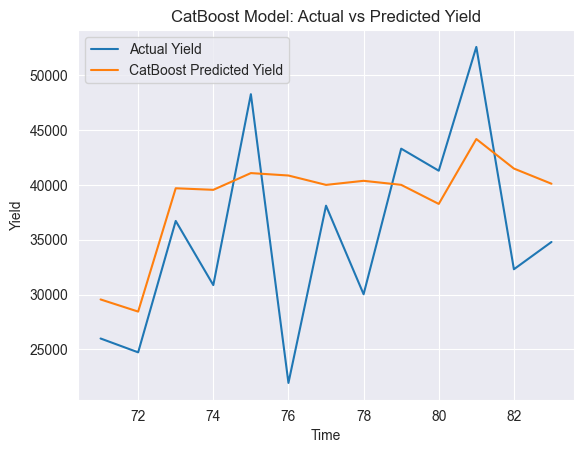

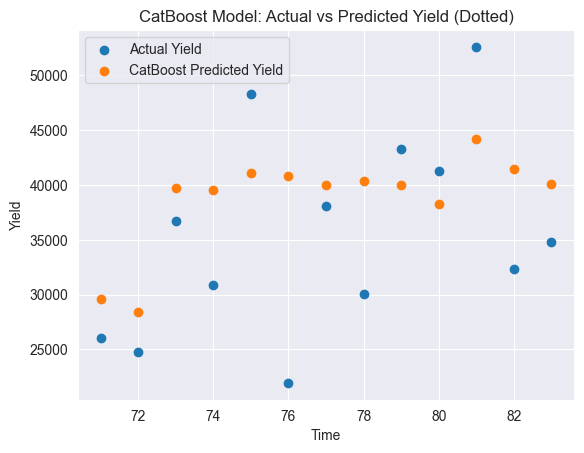

In [31]:
#line plot
plt.figure()

plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_cat, label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

#scatter plot
plt.figure()

plt.scatter(y_test.index, y_test.values,
            label="Actual Yield")

plt.scatter(y_test.index, y_pred_cat,
            label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield (Dotted)")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

Training on XGBoost

In [32]:
#XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [33]:
#PREDICT & UN-SCALE
# The model outputs scaled predictions (small decimals)
y_pred_xgb = xgb_model.predict(x_test_scaled)


In [23]:
#Save trained model and scaler
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")
print("xgb_model.pkl ✓")
print("scaler.pkl    ✓")

Model and scaler saved successfully.
xgb_model.pkl ✓
scaler.pkl    ✓


In [24]:
import json

medians = {
    "rainfall":          {k: float(v) for k, v in rainfall_median_by_month.items()},
    "wet_days":          {k: float(v) for k, v in wet_days_median_by_month.items()},
    "irradiance_SW_DWN": {k: float(v) for k, v in x_train.groupby(df['month'].iloc[:split_idx])['irradiance_SW_DWN'].median().items()},
    "NDVI":              {k: float(v) for k, v in ndvi_median_by_month.items()},
    "EVI":               {k: float(v) for k, v in evi_median_by_month.items()},
    "rainfall_lag_1":    float(rainfall_lag_median),
}

with open("medians.json", "w") as f:
    json.dump(medians, f, indent=2)

print("medians.json saved ✓")
print(json.dumps(medians, indent=2))

medians.json saved ✓
{
  "rainfall": {
    "April": 361.0,
    "August": 1005.0,
    "December": 223.0,
    "February": 83.5,
    "January": 58.0,
    "July": 672.0,
    "June": 509.5,
    "March": 228.0,
    "May": 798.5,
    "November": 303.0,
    "October": 639.5,
    "September": 512.0
  },
  "wet_days": {
    "April": 17.0,
    "August": 20.0,
    "December": 11.5,
    "February": 6.5,
    "January": 8.0,
    "July": 23.0,
    "June": 22.0,
    "March": 9.0,
    "May": 21.0,
    "November": 17.0,
    "October": 25.5,
    "September": 21.0
  },
  "irradiance_SW_DWN": {
    "April": 5.5163,
    "August": 4.8228,
    "December": 4.486549999999999,
    "February": 5.72495,
    "January": 5.265499999999999,
    "July": 4.8826,
    "June": 4.8931000000000004,
    "March": 5.593,
    "May": 4.73385,
    "November": 4.7112,
    "October": 4.3931000000000004,
    "September": 4.5593
  },
  "NDVI": {
    "April": 0.63098,
    "August": 0.643193,
    "December": 0.715949,
    "February": 0.5

In [34]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("Model A — XGBoost Yield Prediction")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Model A — XGBoost Yield Prediction
RMSE: 6143.22
MAE : 5151.27
R²  : 0.514


In [35]:
#MAPE
mape = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100
print(f"MAPE: {mape:.1f}%")

MAPE: 25.8%


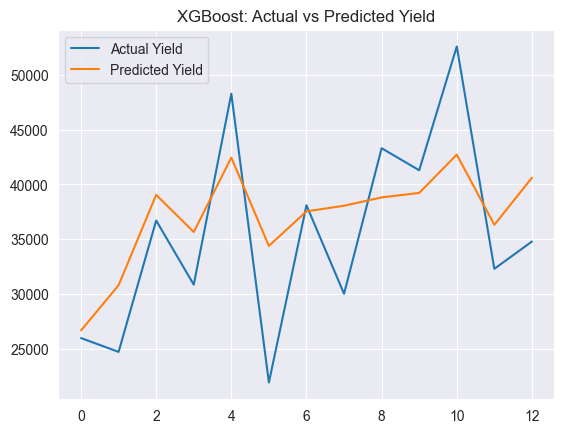

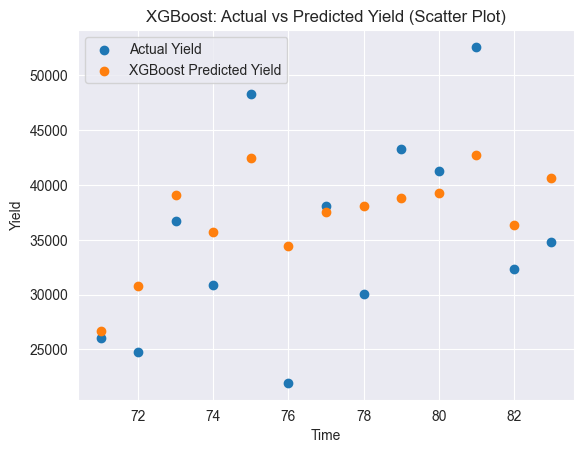

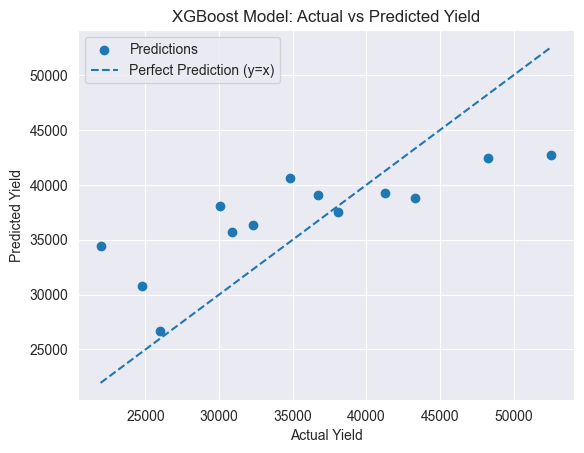

In [38]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_xgb, label="Predicted Yield")
plt.legend()
plt.title("XGBoost: Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_xgb, label="XGBoost Predicted Yield")
plt.legend()
plt.title("XGBoost: Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()


plt.figure()

# scatter plot (Actual vs Predicted)
plt.scatter(y_test.values, y_pred_xgb, label="Predictions")

# perfect prediction / naive baseline line
min_val = min(min(y_test.values), min(y_pred_xgb))
max_val = max(max(y_test.values), max(y_pred_xgb))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect Prediction (y=x)")

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost Model: Actual vs Predicted Yield")
plt.legend()

plt.show()



              feature  importance
            sin_month    0.170842
                 NDVI    0.123421
       rainfall_lag_1    0.082559
         yield_lag_12    0.082475
female_workforceRatio    0.079559
          yield_lag_1    0.077760
            cos_month    0.069045
                  EVI    0.063683
          yield_lag_3    0.054174
             wet_days    0.045633
    irradiance_SW_DWN    0.041993
          yield_lag_2    0.039502
       yield_momentum    0.035087
             rainfall    0.034267


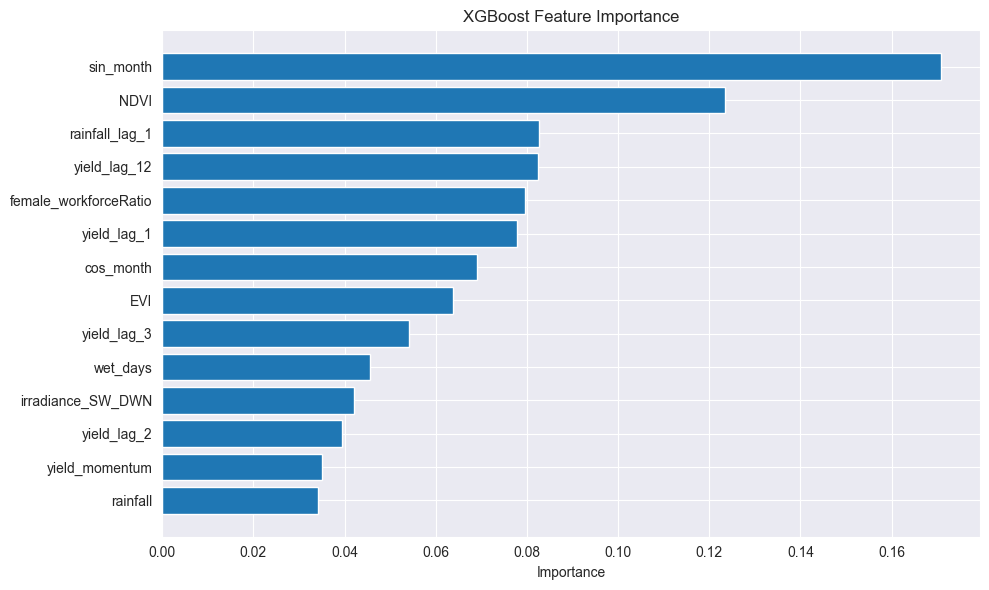

In [39]:
#feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Training on a Neural Network

Tuning Neural Network via Grid Search...
Total combinations: 81

Top 5 configurations:
 batch_size  dropout_rate  hidden_units  learning_rate  val_mse
          8           0.2            64          0.005   0.2207
          8           0.2           128          0.001   0.2274
         16           0.2            64          0.001   0.2556
          8           0.3           128          0.001   0.2557
         32           0.2            32          0.005   0.2625

Best params : {'batch_size': 8, 'dropout_rate': 0.2, 'hidden_units': 64, 'learning_rate': 0.005}
Best val MSE (scaled): 0.2207
Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.4588 - val_loss: 0.5496
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1991 - val_loss: 0.6765
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7033 - val_loss: 0.5632
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6326 - val_loss: 0.5760
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5313 - va

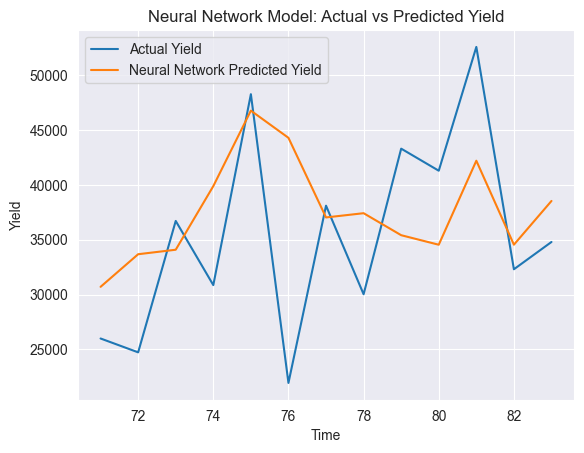

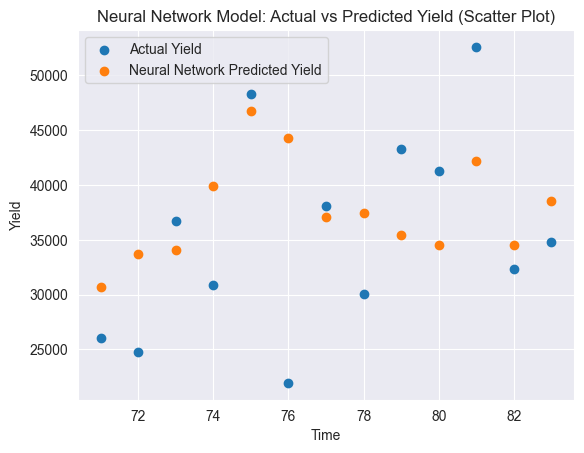

In [43]:
#NEURAL NETWORK MODEL
# Simple MLP added for comparison against tree-based models.Uses the same x_train_scaled / x_test_scaled as XGBoost and CatBoost.
#The target (yield) is separately scaled for stable NN training
# then inverse-transformed before metrics are computed.


#Scale the target variable
y_scaler = StandardScaler()
y_train_nn = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_nn  = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

#Hyperparameter Tuning — Grid Search
param_grid = {
    'hidden_units':  [32, 64, 128],
    'dropout_rate':  [0.1, 0.2, 0.3],
    'learning_rate': [0.0005, 0.001, 0.005],
    'batch_size':    [8, 16, 32],
}

best_nn_val_loss = float('inf')
best_nn_params   = None
tuning_results   = []

print("Tuning Neural Network via Grid Search...")
print(f"Total combinations: {len(list(ParameterGrid(param_grid)))}")
print("=" * 65)

for params in ParameterGrid(param_grid):
    model_tmp = Sequential([
        Dense(params['hidden_units'], activation='relu',
              input_shape=(x_train_scaled.shape[1],)),
        Dropout(params['dropout_rate']),
        Dense(params['hidden_units'] // 2, activation='relu'),
        Dropout(params['dropout_rate']),
        Dense(1)  # single output neuron — regression task
    ])
    model_tmp.compile(
        optimizer=Adam(learning_rate=params['learning_rate']),
        loss='mse'  # MSE on scaled y — equivalent to minimising RMSE
    )
    es_tmp = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )
    history_tmp = model_tmp.fit(
        x_train_scaled, y_train_nn,
        validation_data=(x_test_scaled, y_test_nn),
        epochs=300,
        batch_size=params['batch_size'],
        callbacks=[es_tmp],
        verbose=0
    )
    val_loss = min(history_tmp.history['val_loss'])
    tuning_results.append({**params, 'val_mse': round(val_loss, 4)})

    if val_loss < best_nn_val_loss:
        best_nn_val_loss = val_loss
        best_nn_params   = params

# Print tuning summary — top 5 by val MSE
tuning_df = pd.DataFrame(tuning_results).sort_values('val_mse')
print("\nTop 5 configurations:")
print(tuning_df.head(5).to_string(index=False))
print(f"\nBest params : {best_nn_params}")
print(f"Best val MSE (scaled): {best_nn_val_loss:.4f}")
print("=" * 65)

#Train final model with best hyperparameters
nn_model = Sequential([
    Dense(best_nn_params['hidden_units'], activation='relu',
          input_shape=(x_train_scaled.shape[1],)),
    Dropout(best_nn_params['dropout_rate']),
    Dense(best_nn_params['hidden_units'] // 2, activation='relu'),
    Dropout(best_nn_params['dropout_rate']),
    Dense(1)
])

nn_model.compile(
    optimizer=Adam(learning_rate=best_nn_params['learning_rate']),
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

nn_history = nn_model.fit(
    x_train_scaled, y_train_nn,
    validation_data=(x_test_scaled, y_test_nn),
    epochs=500,
    batch_size=best_nn_params['batch_size'],
    callbacks=[early_stop],
    verbose=1
)

#Predict and inverse-transform back to original kg scale
y_pred_nn_scaled = nn_model.predict(x_test_scaled).flatten()
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).flatten()

#Metrics (on original scale — same as all other models)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_mae  = mean_absolute_error(y_test, y_pred_nn)
nn_r2   = r2_score(y_test, y_pred_nn)

print("\nNeural Network Yield Prediction Performance")
print(f"RMSE: {nn_rmse:.2f}")
print(f"MAE : {nn_mae:.2f}")
print(f"R²  : {nn_r2:.3f}")

#Visualization 1 — Line plot
plt.figure()
plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_nn,     label="Neural Network Predicted Yield")
plt.legend()
plt.title("Neural Network Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()

#Visualization 2 — Scatter plot
plt.figure()
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_nn,     label="Neural Network Predicted Yield")
plt.legend()
plt.title("Neural Network Model: Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()

In [44]:
#Define the data with units and rounded values
results = [
    {
        "Model Name": "XGBoost",
        "RMSE (kg)": f"{np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}",
        "MAE (kg)": f"{mean_absolute_error(y_test, y_pred_xgb):.2f}",
        "R² Score": f"{r2_score(y_test, y_pred_xgb):.3f}"
    },
    {
        "Model Name": "CatBoost",
        "RMSE (kg)": f"{np.sqrt(mean_squared_error(y_test, y_pred_cat)):.2f}",
        "MAE (kg)": f"{mean_absolute_error(y_test, y_pred_cat):.2f}",
        "R² Score": f"{r2_score(y_test, y_pred_cat):.3f}"
    },
    {
        "Model Name": "SARIMAX",
        "RMSE (kg)": f"{sarimax_rmse:.2f}",
        "MAE (kg)":  f"{sarimax_mae:.2f}",
        "R² Score":  f"{sarimax_r2:.3f}"
    },
    {
        "Model Name": "Neural Network",
        "RMSE (kg)": f"{nn_rmse:.2f}",
        "MAE (kg)":  f"{nn_mae:.2f}",
        "R² Score":  f"{nn_r2:.3f}"
    }
]

#Create DataFrame
comparison_df = pd.DataFrame(results)

#Print with extra spacing
print("\n" + "="*60)
print("              MODEL PERFORMANCE COMPARISON")
print("="*60 + "\n")

#Using to_string with justify and col_space for a "spacious" look
print(comparison_df.to_string(index=False, justify='center', col_space=15))

print("\n" + "="*60)


              MODEL PERFORMANCE COMPARISON

   Model Name      RMSE (kg)        MAE (kg)        R² Score   
        XGBoost     6143.22         5151.27          0.514     
       CatBoost     8004.96         6650.79          0.174     
        SARIMAX     8565.62         7973.97          0.054     
 Neural Network     8689.18         6812.94          0.027     



  PREDICTED YIELD — MARCH 2025
  Predicted Yield  : 40,614 kg
  Expected Range   : 34,470 kg — 46,757 kg
  vs March 2024        : 26,003 kg
  Year-over-Year   : ↑ 56.2%


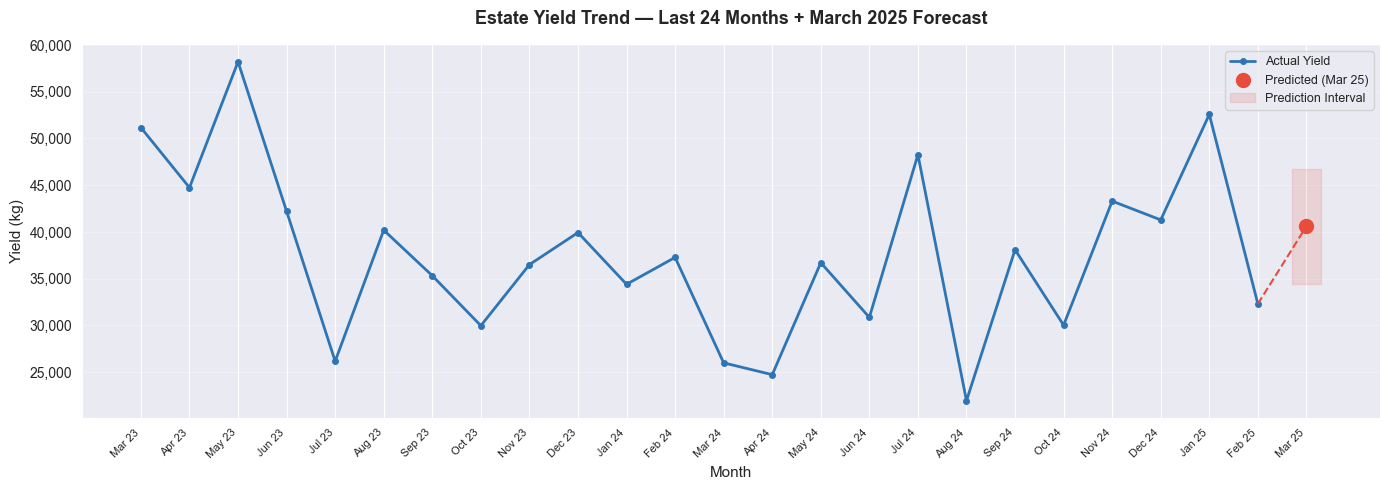

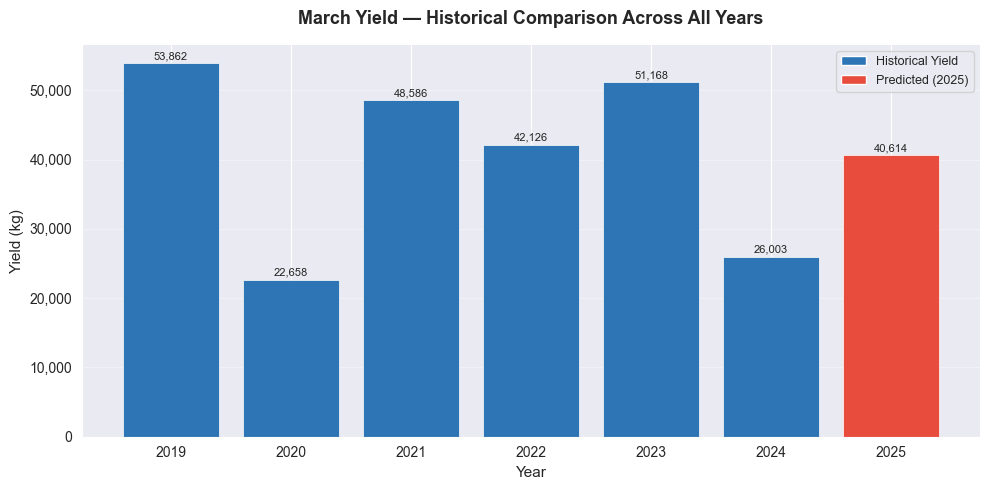

In [45]:
# ESTATE PRODUCTION FORECASTING — DASHBOARD VISUALIZATIONS
# Using the last test row as the "predicted next month" point for testing

RMSE_INTERVAL = 6143.22  # model RMSE used as prediction interval

#identify the predicted month
last_idx        = len(df) - 1
predicted_month = df.iloc[last_idx]['month']
predicted_year  = df.iloc[last_idx]['year']
predicted_yield = float(y_pred_xgb[-1])
lower_bound     = predicted_yield - RMSE_INTERVAL
upper_bound     = predicted_yield + RMSE_INTERVAL

#same month last year for YoY
same_month_last_year_row = df[
    (df['month'] == predicted_month) &
    (df['year']  == predicted_year - 1)
]
if not same_month_last_year_row.empty:
    last_year_yield = float(same_month_last_year_row['yield'].values[0])
    yoy_change      = ((predicted_yield - last_year_yield) / last_year_yield) * 100
    yoy_direction   = '↑' if yoy_change > 0 else '↓'
else:
    last_year_yield = None
    yoy_change      = None

#historical data = everything before the predicted row
historical_df = df.iloc[:last_idx].copy()


# STAT CARD — Predicted Yield + Interval + YoY
print("=" * 55)
print(f"  PREDICTED YIELD — {predicted_month.upper()} {predicted_year}")
print("=" * 55)
print(f"  Predicted Yield  : {predicted_yield:,.0f} kg")
print(f"  Expected Range   : {lower_bound:,.0f} kg — {upper_bound:,.0f} kg")
if yoy_change is not None:
    print(f"  vs {predicted_month} {predicted_year - 1}        : {last_year_yield:,.0f} kg")
    print(f"  Year-over-Year   : {yoy_direction} {abs(yoy_change):.1f}%")
print("=" * 55)


# CHART 1 — Yield Trend: Last 24 Months + Predicted Point
hist_24 = historical_df.tail(24).copy()

# build labels for x axis
hist_24['label'] = hist_24['month'].str[:3] + ' ' + hist_24['year'].astype(str).str[-2:]
pred_label       = predicted_month[:3] + ' ' + str(predicted_year)[-2:]

fig, ax = plt.subplots(figsize=(14, 5))

# historical line
ax.plot(
    range(len(hist_24)),
    hist_24['yield'].values,
    color='#2E75B6', linewidth=2, marker='o', markersize=4, label='Actual Yield'
)

# dashed connector to predicted point
ax.plot(
    [len(hist_24) - 1, len(hist_24)],
    [hist_24['yield'].values[-1], predicted_yield],
    color='#E74C3C', linewidth=1.5, linestyle='--'
)

# predicted point
ax.scatter(
    len(hist_24), predicted_yield,
    color='#E74C3C', s=100, zorder=5, label=f'Predicted ({pred_label})'
)

# prediction interval shading
ax.fill_between(
    [len(hist_24) - 0.3, len(hist_24) + 0.3],
    lower_bound, upper_bound,
    color='#E74C3C', alpha=0.15, label='Prediction Interval'
)

# x axis labels
all_labels = list(hist_24['label'].values) + [pred_label]
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)

ax.set_title(f'Estate Yield Trend — Last 24 Months + {predicted_month} {predicted_year} Forecast',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Yield (kg)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


# CHART 2 — Same Month Historical Comparison (all available years)
same_month_hist = df[df['month'] == predicted_month].copy()
same_month_hist = same_month_hist[same_month_hist['year'] < predicted_year]

years  = list(same_month_hist['year'].values) + [predicted_year]
yields = list(same_month_hist['yield'].values) + [predicted_yield]
colors = ['#2E75B6'] * len(same_month_hist) + ['#E74C3C']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [str(y) for y in years],
    yields,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# value labels on bars
for bar, val in zip(bars, yields):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=8
    )

# legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E75B6', label='Historical Yield'),
    Patch(facecolor='#E74C3C', label=f'Predicted ({predicted_year})')
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_title(f'{predicted_month} Yield — Historical Comparison Across All Years',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Yield (kg)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()